In [ ]:
!pip install qiskit
!pip install qiskit_aer
!pip install matplotlib pylatexenc
!pip install numpy

--- Running Noisy Deutsch Algorithm ---
--> NOISE INJECTED: Phase Flip (Z) on Qubit 0
Constant Oracle (with Noise) Result: {'1': 100}


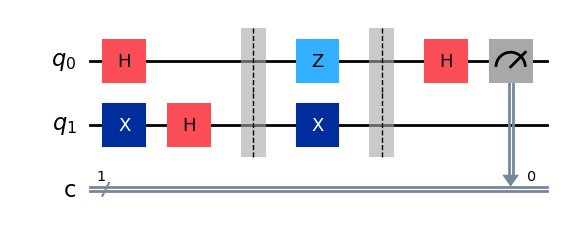

In [ ]:

import numpy as np
import random
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# 1. Function to inject random X (Bit) or Z (Phase) errors
def add_noise(qc, qubit_target, probability=0.4):
    """Injects a random error with a given probability."""
    if random.random() < probability:
        error_type = random.choice(['X', 'Z'])
        if error_type == 'X':
            qc.x(qubit_target)
            print(f"--> NOISE INJECTED: Bit Flip (X) on Qubit {qubit_target}")
        else:
            qc.z(qubit_target)
            print(f"--> NOISE INJECTED: Phase Flip (Z) on Qubit {qubit_target}")

# Your original functions (untouched)
def initialcircuit():
    qc = QuantumCircuit(2, 1)
    qc.x(1)
    qc.h(0)
    qc.h(1)
    qc.barrier()
    return qc

def constant_oracle():
    qc = QuantumCircuit(2, 1)
    qc.x(1)
    qc.barrier()
    return qc

def balanced_oracle():
    qc = QuantumCircuit(2, 1)
    qc.cx(0, 1)
    qc.barrier()
    return qc

def measure():
    qc = QuantumCircuit(2, 1)
    qc.h(0)
    qc.measure(0, 0)
    return qc

# --- SIMULATION ---
simulator = AerSimulator()

print("--- Running Noisy Deutsch Algorithm ---")

# Let's test just the Constant Oracle (Should always be 0)
name = "Constant"
oracle = constant_oracle()

qc = initialcircuit()

# !!! INJECT NOISE HERE !!!
# We add noise to Qubit 0 (the data qubit) before the oracle
add_noise(qc, qubit_target=0, probability=0.8) # High probability to ensure you see it

qc = qc.compose(oracle)
qc = qc.compose(measure())

result = simulator.run(qc, shots=100).result()
counts = result.get_counts()

print(f"{name} Oracle (with Noise) Result:", counts)
# If you see '1', the noise broke the algorithm!

display(qc.draw("mpl"))

Injecting noise into Shor Circuit...
--> NOISE INJECTED: Phase Flip (Z) on Qubit 0

--- Running Shor's 9-Bit Code ---
Final Result (Should be {'1': 100} if corrected): {'1': 100}


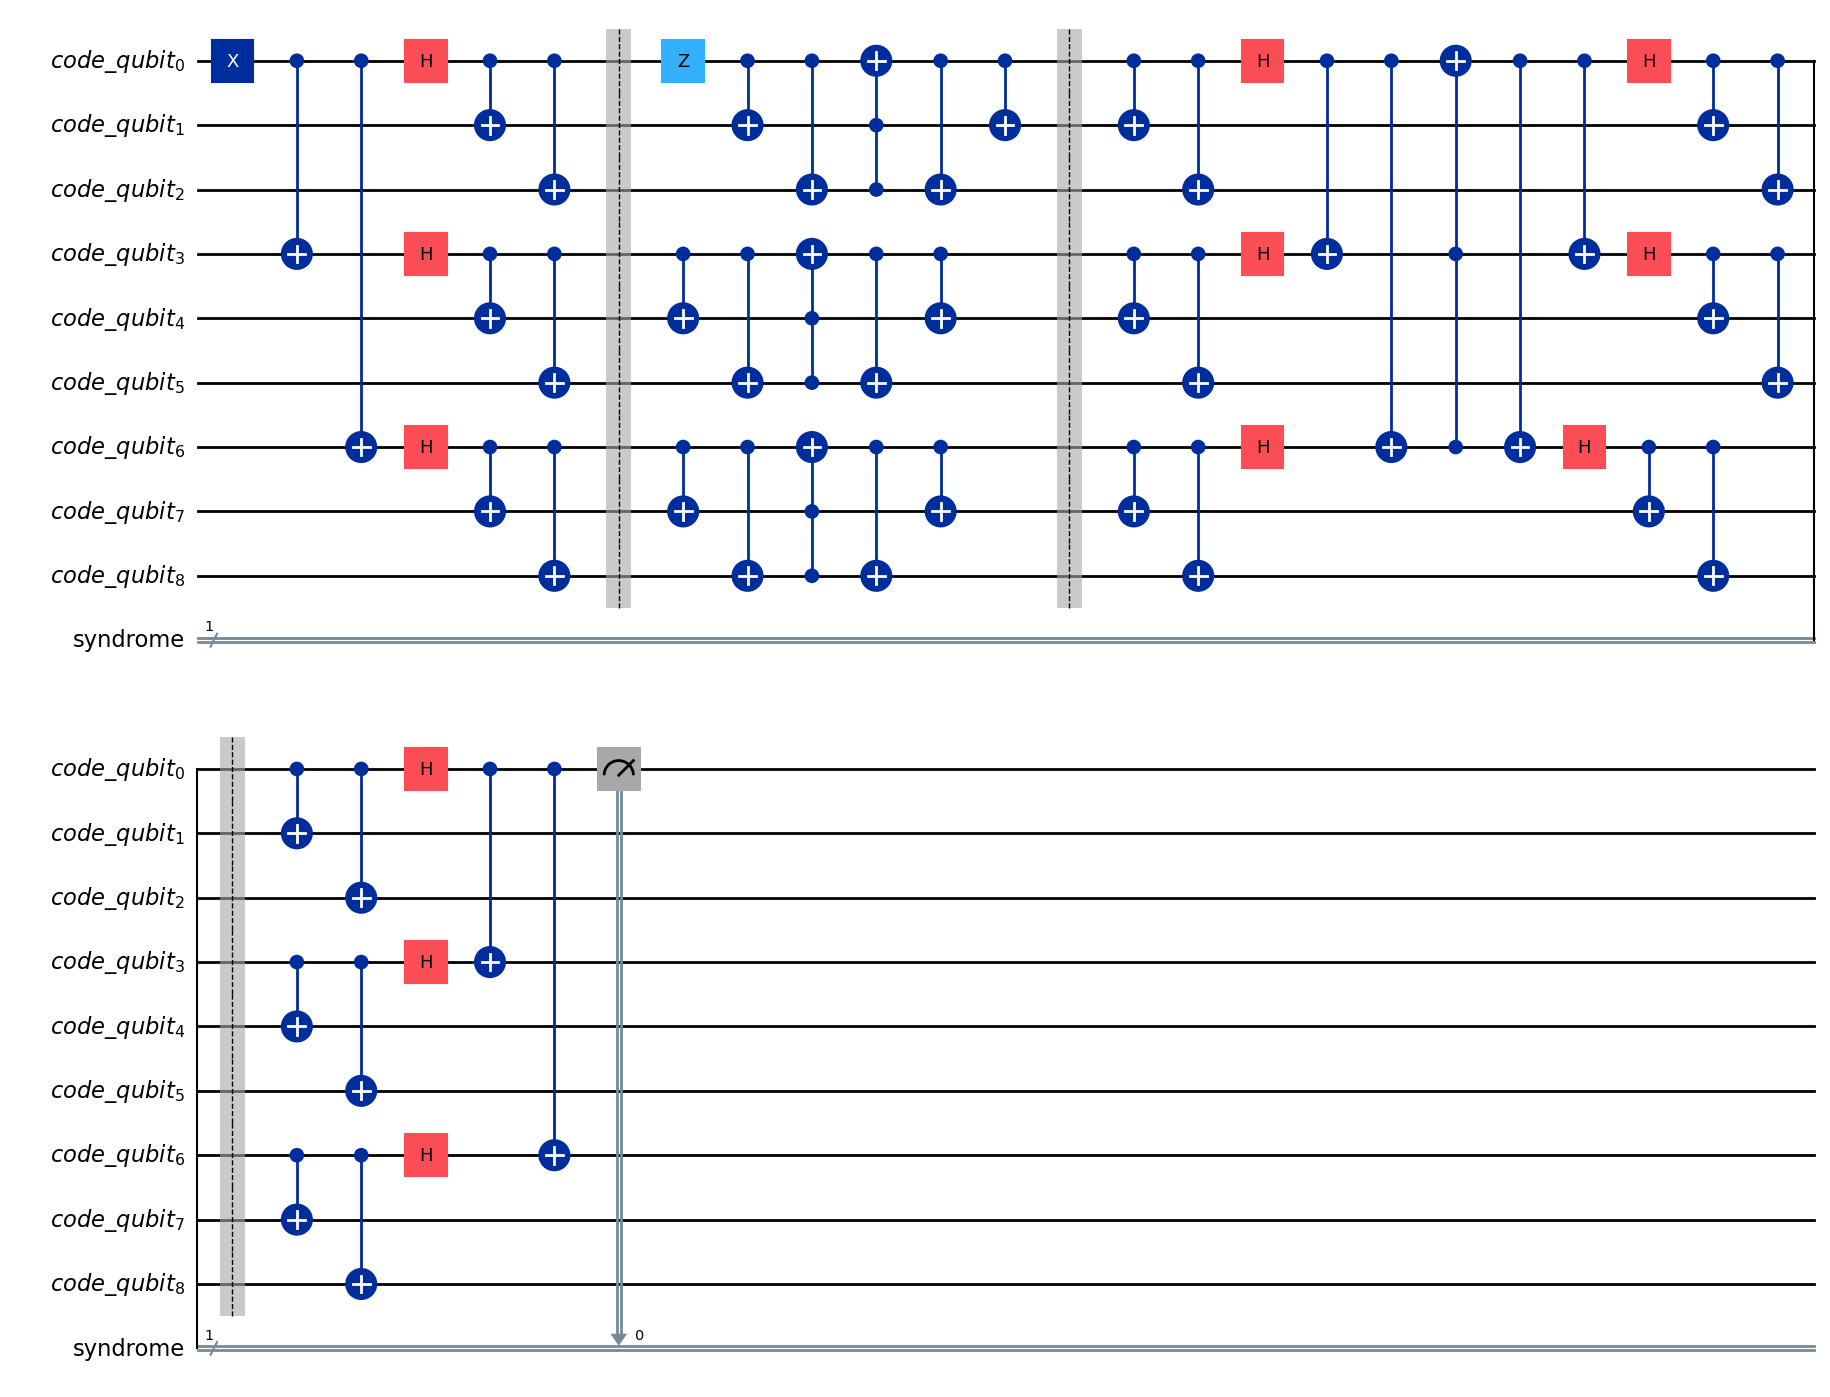

In [ ]:

from qiskit import QuantumRegister, ClassicalRegister

def shor_encode(qc):
    """Encodes 1 qubit into 9 qubits (Shor Code)"""
    # Phase Flip Protection (Outer Layer)
    qc.cx(0, 3)
    qc.cx(0, 6)
    qc.h(0)
    qc.h(3)
    qc.h(6)

    # Bit Flip Protection (Inner Layer)
    qc.cx(0, 1); qc.cx(0, 2)
    qc.cx(3, 4); qc.cx(3, 5)
    qc.cx(6, 7); qc.cx(6, 8)
    qc.barrier()

def shor_correct(qc):
    """Robust Correction: Decodes inner layer to fix phase flips"""

    # --- PART A: Bit Flip Correction (Inner Layer) ---
    # This checks for X errors inside each group
    for i in [0, 3, 6]:
        qc.cx(i, i+1)
        qc.cx(i, i+2)
        qc.ccx(i+1, i+2, i) # Correction
        qc.cx(i, i+2)       # Cleanup
        qc.cx(i, i+1)       # Cleanup
    qc.barrier()

    # --- PART B: Phase Flip Correction (Outer Layer) ---

    # 1. DECODE the inner bit-flip layer
    # This concentrates the phase information onto 0, 3, 6
    # (We reverse the CNOTs that created the 000/111 states)
    qc.cx(0, 1); qc.cx(0, 2)
    qc.cx(3, 4); qc.cx(3, 5)
    qc.cx(6, 7); qc.cx(6, 8)

    # 2. Correct the Phase Flip on the leaders
    # Now qubits 0, 3, 6 behave like a simple 3-qubit code
    qc.h(0); qc.h(3); qc.h(6) # Switch to Z-basis

    qc.cx(0, 3)
    qc.cx(0, 6)
    qc.ccx(3, 6, 0) # If 3 and 6 disagree with 0, flip 0
    qc.cx(0, 6)     # Cleanup
    qc.cx(0, 3)     # Cleanup

    qc.h(0); qc.h(3); qc.h(6) # Switch back

    # 3. RE-ENCODE the inner bit-flip layer
    # We must restore the protection before finishing
    qc.cx(0, 1); qc.cx(0, 2)
    qc.cx(3, 4); qc.cx(3, 5)
    qc.cx(6, 7); qc.cx(6, 8)

    qc.barrier()



def shor_decode(qc):
    """Decodes 9 qubits back to 1"""
    # Reverse Bit Flip encoding
    qc.cx(0, 1); qc.cx(0, 2)
    qc.cx(3, 4); qc.cx(3, 5)
    qc.cx(6, 7); qc.cx(6, 8)

    # Reverse Phase Flip encoding
    qc.h(0); qc.h(3); qc.h(6)
    qc.cx(0, 3); qc.cx(0, 6)

# --- THE FULL SIMULATION ---

# 1. Setup 9 Qubits
qr = QuantumRegister(9, 'code_qubit')
cr = ClassicalRegister(1, 'syndrome')
qc_shor = QuantumCircuit(qr, cr)

# 2. Initialize State (e.g., Logical |1>)
# We start with |1> so we can verify if it flips back to 0
qc_shor.x(0)

# 3. Encode
shor_encode(qc_shor)

# 4. !!! INJECT RANDOM NOISE !!!
# Try changing this index (0-8) or type (x or z)
print("Injecting noise into Shor Circuit...")
add_noise(qc_shor, qubit_target=0, probability=1.0)

# 5. Run Correction
shor_correct(qc_shor)

# 6. Decode
shor_decode(qc_shor)

# 7. Measure the final logical qubit
qc_shor.measure(0, 0)

# Run
print("\n--- Running Shor's 9-Bit Code ---")
result = simulator.run(qc_shor, shots=100).result()
print("Final Result (Should be {'1': 100} if corrected):", result.get_counts())

display(qc_shor.draw("mpl"))

Generating 100 unique timelines...
Running batch simulation...

--- NOISE STATISTICS ---
Total Shots: 100
Shots with X Errors (Harmless): 43
Shots with Z Errors (Fatal):    43
Shots Clean:                    14

--- FINAL MEASUREMENT RESULTS ---
Result '0' (Correct): 57
Result '1' (Wrong):   43

Example of one random circuit from the batch:


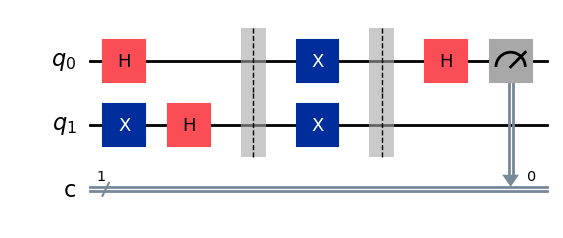

In [ ]:
import numpy as np
import random
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# --- YOUR ORIGINAL FUNCTIONS (Kept exactly as they were) ---
def add_noise(qc, qubit_target, probability=0.4):
    """Injects a random error with a given probability."""
    if random.random() < probability:
        error_type = random.choice(['X', 'Z'])
        if error_type == 'X':
            qc.x(qubit_target)
            return "X Error" # Returning string to log it
        else:
            qc.z(qubit_target)
            return "Z Error"
    return "Clean"

def initialcircuit():
    qc = QuantumCircuit(2, 1)
    qc.x(1)
    qc.h(0); qc.h(1)
    qc.barrier()
    return qc

def constant_oracle():
    qc = QuantumCircuit(2, 1)
    qc.x(1)
    qc.barrier()
    return qc

def measure():
    qc = QuantumCircuit(2, 1)
    qc.h(0)
    qc.measure(0, 0)
    return qc

# --- NEW BATCH SIMULATION SECTION ---
simulator = AerSimulator()
circuits = []      # List to hold 100 different circuits
noise_logs = []    # List to track what happened in each shot

print("Generating 100 unique timelines...")

# 1. Create 100 unique circuits
for i in range(100):
    # A. Build the base circuit
    qc = initialcircuit()

    # B. Inject Random Noise (Unique for this specific 'i')
    # We add it to Qubit 0 before the oracle
    error_log = add_noise(qc, qubit_target=0, probability=0.8)
    noise_logs.append(error_log)

    # C. Finish the circuit
    qc = qc.compose(constant_oracle())
    qc = qc.compose(measure())

    # D. Add to our batch list
    circuits.append(qc)

print("Running batch simulation...")

# 2. Run all 100 circuits at once (1 shot each)
result = simulator.run(circuits, shots=1).result()

# 3. Aggregate the results
total_counts = {'0': 0, '1': 0}
x_errors = 0
z_errors = 0

for i in range(100):
    # Get result for circuit #i
    counts = result.get_counts(i)

    # Tally up the final measurement
    if '0' in counts: total_counts['0'] += 1
    if '1' in counts: total_counts['1'] += 1

    # Tally up the cause (just for our info)
    if noise_logs[i] == "X Error": x_errors += 1
    if noise_logs[i] == "Z Error": z_errors += 1

print("\n--- NOISE STATISTICS ---")
print(f"Total Shots: 100")
print(f"Shots with X Errors (Harmless): {x_errors}")
print(f"Shots with Z Errors (Fatal):    {z_errors}")
print(f"Shots Clean:                    {100 - x_errors - z_errors}")

print("\n--- FINAL MEASUREMENT RESULTS ---")
print(f"Result '0' (Correct): {total_counts['0']}")
print(f"Result '1' (Wrong):   {total_counts['1']}")

# Draw just the last circuit as an example
print("\nExample of one random circuit from the batch:")
display(circuits[-1].draw("mpl"))

Generating 100 unique timelines...
Running batch simulation...

--- NOISE STATISTICS ---
X Errors: 46, Z Errors: 41, Clean: 13

--- FINAL RESULTS ---
Result '1' (Correct): 100
Result '0' (Failed):  0

SUCCESS: The logical oracle preserved the data perfectly despite noise.

Diagram of the Logical Oracle Section:


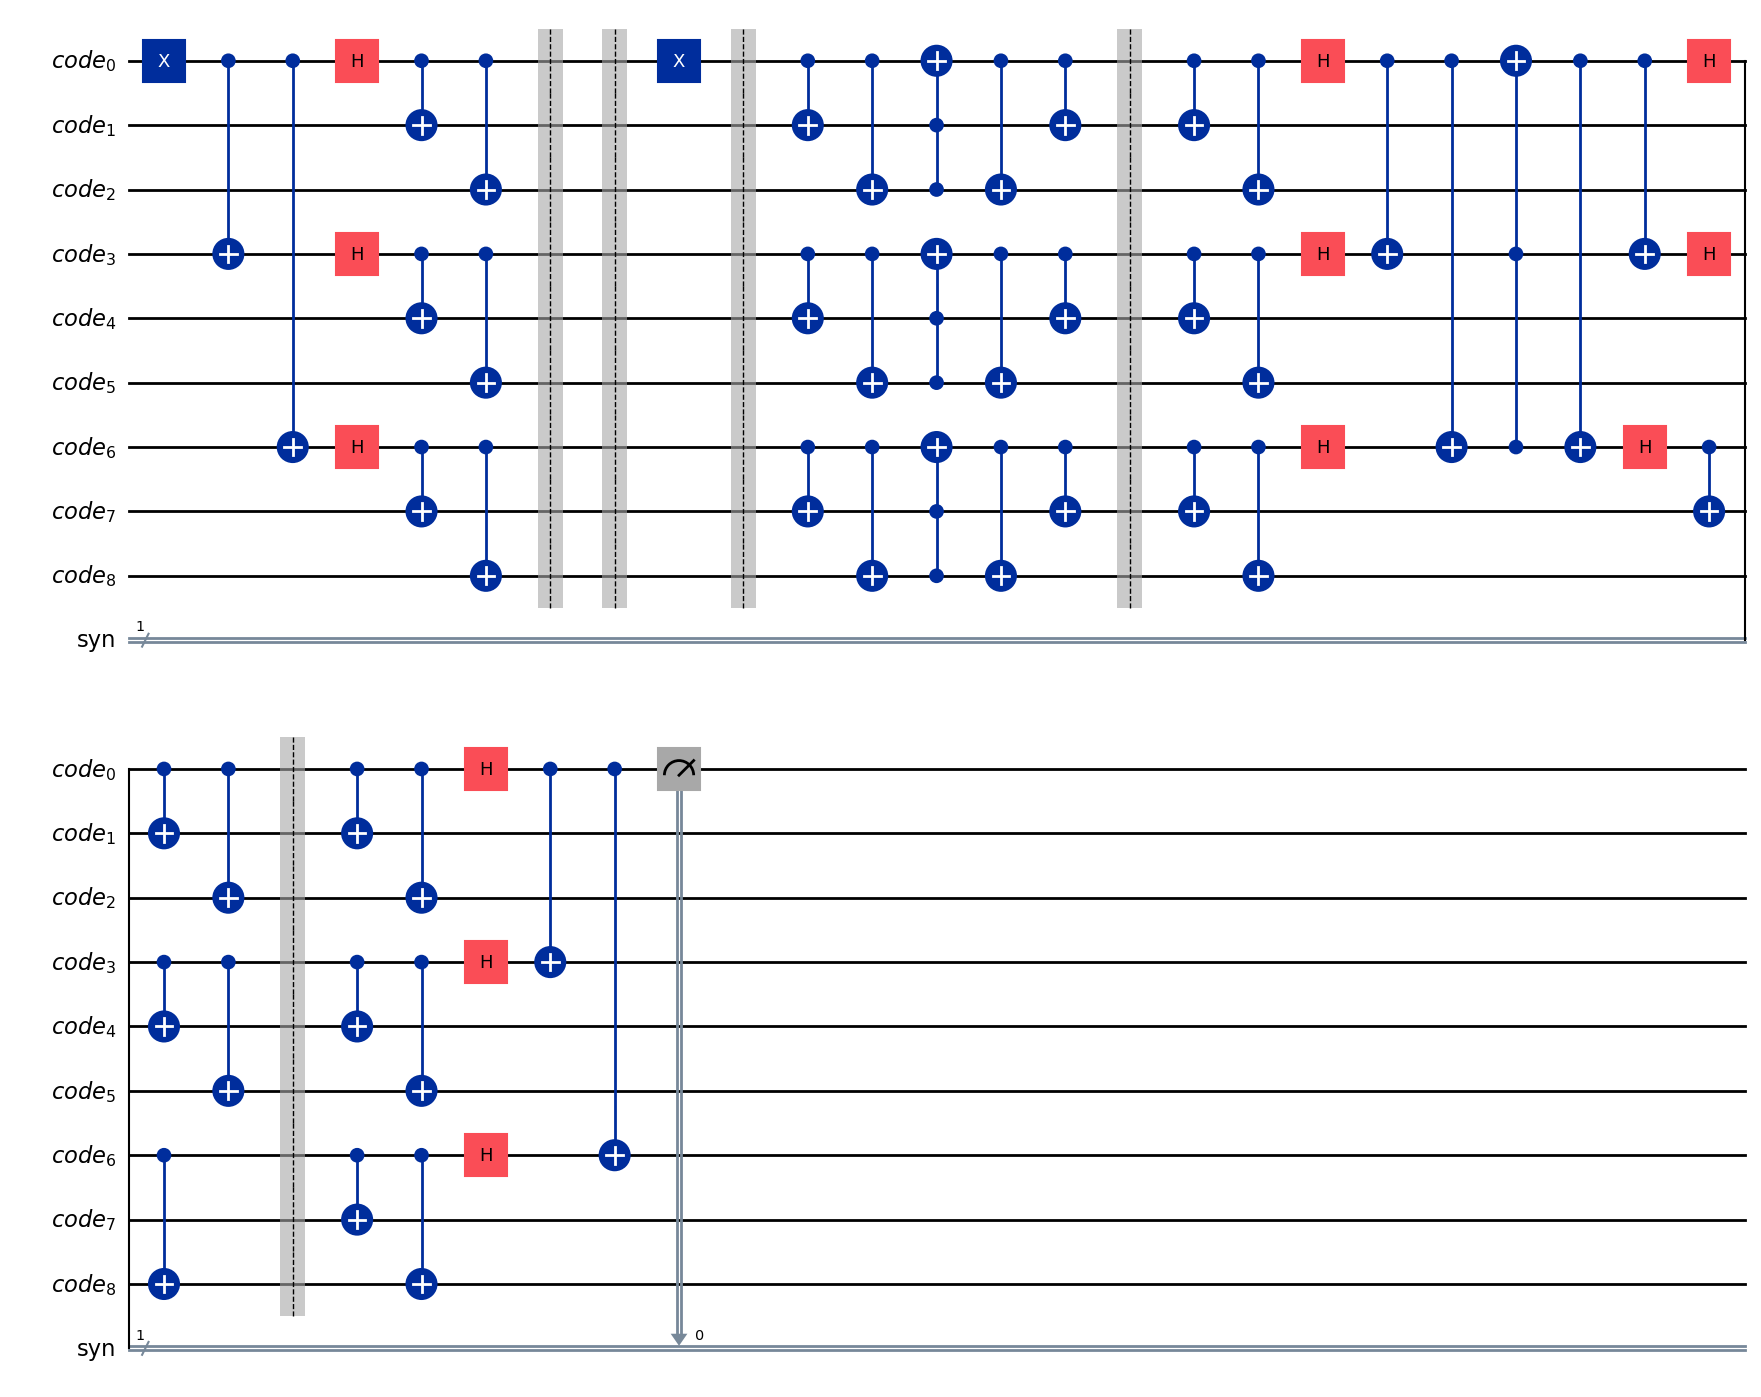

In [ ]:
#with initial state ket one

import numpy as np
import random
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# --- 1. SHOR CODE FUNCTIONS ---

def shor_encode(qc):
    """Encodes 1 qubit into 9 qubits"""
    qc.cx(0, 3); qc.cx(0, 6)
    qc.h(0); qc.h(3); qc.h(6)
    qc.cx(0, 1); qc.cx(0, 2)
    qc.cx(3, 4); qc.cx(3, 5)
    qc.cx(6, 7); qc.cx(6, 8)
    qc.barrier()

def shor_correct(qc):
    """Corrects errors on the 9-qubit block"""
    # Bit Flip Correction
    for i in [0, 3, 6]:
        qc.cx(i, i+1); qc.cx(i, i+2)
        qc.ccx(i+1, i+2, i)
        qc.cx(i, i+2); qc.cx(i, i+1)
    qc.barrier()

    # Phase Flip Correction
    qc.cx(0, 1); qc.cx(0, 2); qc.cx(3, 4); qc.cx(3, 5); qc.cx(6, 7); qc.cx(6, 8) # Decode inner
    qc.h(0); qc.h(3); qc.h(6)
    qc.cx(0, 3); qc.cx(0, 6)
    qc.ccx(3, 6, 0) # Correction
    qc.cx(0, 6); qc.cx(0, 3)
    qc.h(0); qc.h(3); qc.h(6)
    qc.cx(0, 1); qc.cx(0, 2); qc.cx(3, 4); qc.cx(3, 5); qc.cx(6, 7); qc.cx(6, 8) # Re-encode
    qc.barrier()

def shor_decode(qc):
    """Decodes 9 qubits back to 1"""
    qc.cx(0, 1); qc.cx(0, 2)
    qc.cx(3, 4); qc.cx(3, 5)
    qc.cx(6, 7); qc.cx(6, 8)
    qc.h(0); qc.h(3); qc.h(6)
    qc.cx(0, 3); qc.cx(0, 6)

# --- 2. THE LOGICAL ORACLE (Modified for 9 Qubits) ---

def add_noise(qc, probability=0.8):
    """Injects random noise into the system"""
    # We attack Qubit 0 (part of the code), but you could randomise this index
    if random.random() < probability:
        error_type = random.choice(['X', 'Z'])
        target_qubit = 0 # Error hits the first qubit of the block
        if error_type == 'X':
            qc.x(target_qubit)
            return "X Error"
        else:
            qc.z(target_qubit)
            return "Z Error"
    return "Clean"

def logical_constant_oracle(qc):
    """
    Simulates a Constant Oracle passing over the 9-qubit code.
    Since it is 'Constant', it does NOT change the data state (Identity).
    HOWEVER, this is where the noise attacks!
    """
    qc.barrier() # Start of Oracle

    # --- NOISE INJECTION HAPPENS HERE ---
    # The oracle is running, and nature attacks the hardware:
    log = add_noise(qc, probability=0.8)

    qc.barrier() # End of Oracle
    return log

# --- 3. BATCH SIMULATION ---

simulator = AerSimulator()
circuits = []
noise_logs = []

print("Generating 100 unique timelines...")

for i in range(100):
    # A. Setup Circuit
    qr = QuantumRegister(9, 'code')
    cr = ClassicalRegister(1, 'syn')
    qc = QuantumCircuit(qr, cr)

    # B. Initialize (Logical |1>)
    qc.x(0)

    # C. Encode
    shor_encode(qc)

    # D. APPLY LOGICAL ORACLE (Includes Noise)
    # This replaces the naked "add_noise" call from before
    log = logical_constant_oracle(qc)
    noise_logs.append(log)

    # E. Correct
    shor_correct(qc)

    # F. Decode
    shor_decode(qc)

    # G. Measure
    qc.measure(0, 0)

    circuits.append(qc)

print("Running batch simulation...")
result = simulator.run(circuits, shots=1).result()

# --- 4. ANALYSIS ---

total_counts = {'0': 0, '1': 0}
x_count = 0; z_count = 0

for i in range(100):
    counts = result.get_counts(i)
    if '0' in counts: total_counts['0'] += 1
    if '1' in counts: total_counts['1'] += 1

    if noise_logs[i] == "X Error": x_count += 1
    if noise_logs[i] == "Z Error": z_count += 1

print("\n--- NOISE STATISTICS ---")
print(f"X Errors: {x_count}, Z Errors: {z_count}, Clean: {100 - x_count - z_count}")

print("\n--- FINAL RESULTS ---")
print(f"Result '1' (Correct): {total_counts['1']}")
print(f"Result '0' (Failed):  {total_counts['0']}")

if total_counts['1'] == 100:
    print("\nSUCCESS: The logical oracle preserved the data perfectly despite noise.")

print("\nDiagram of the Logical Oracle Section:")
display(circuits[-1].draw("mpl"))

Generating 100 unique Deutsch Algorithm timelines...
Running batch simulation...

--- NOISE STATISTICS ---
X Errors: 40, Z Errors: 41, Clean: 19

--- FINAL RESULTS ---
Result '0' (Constant/Success): 100
Result '1' (Error/Failure):    0

SUCCESS: The Shor Code preserved the superposition state!


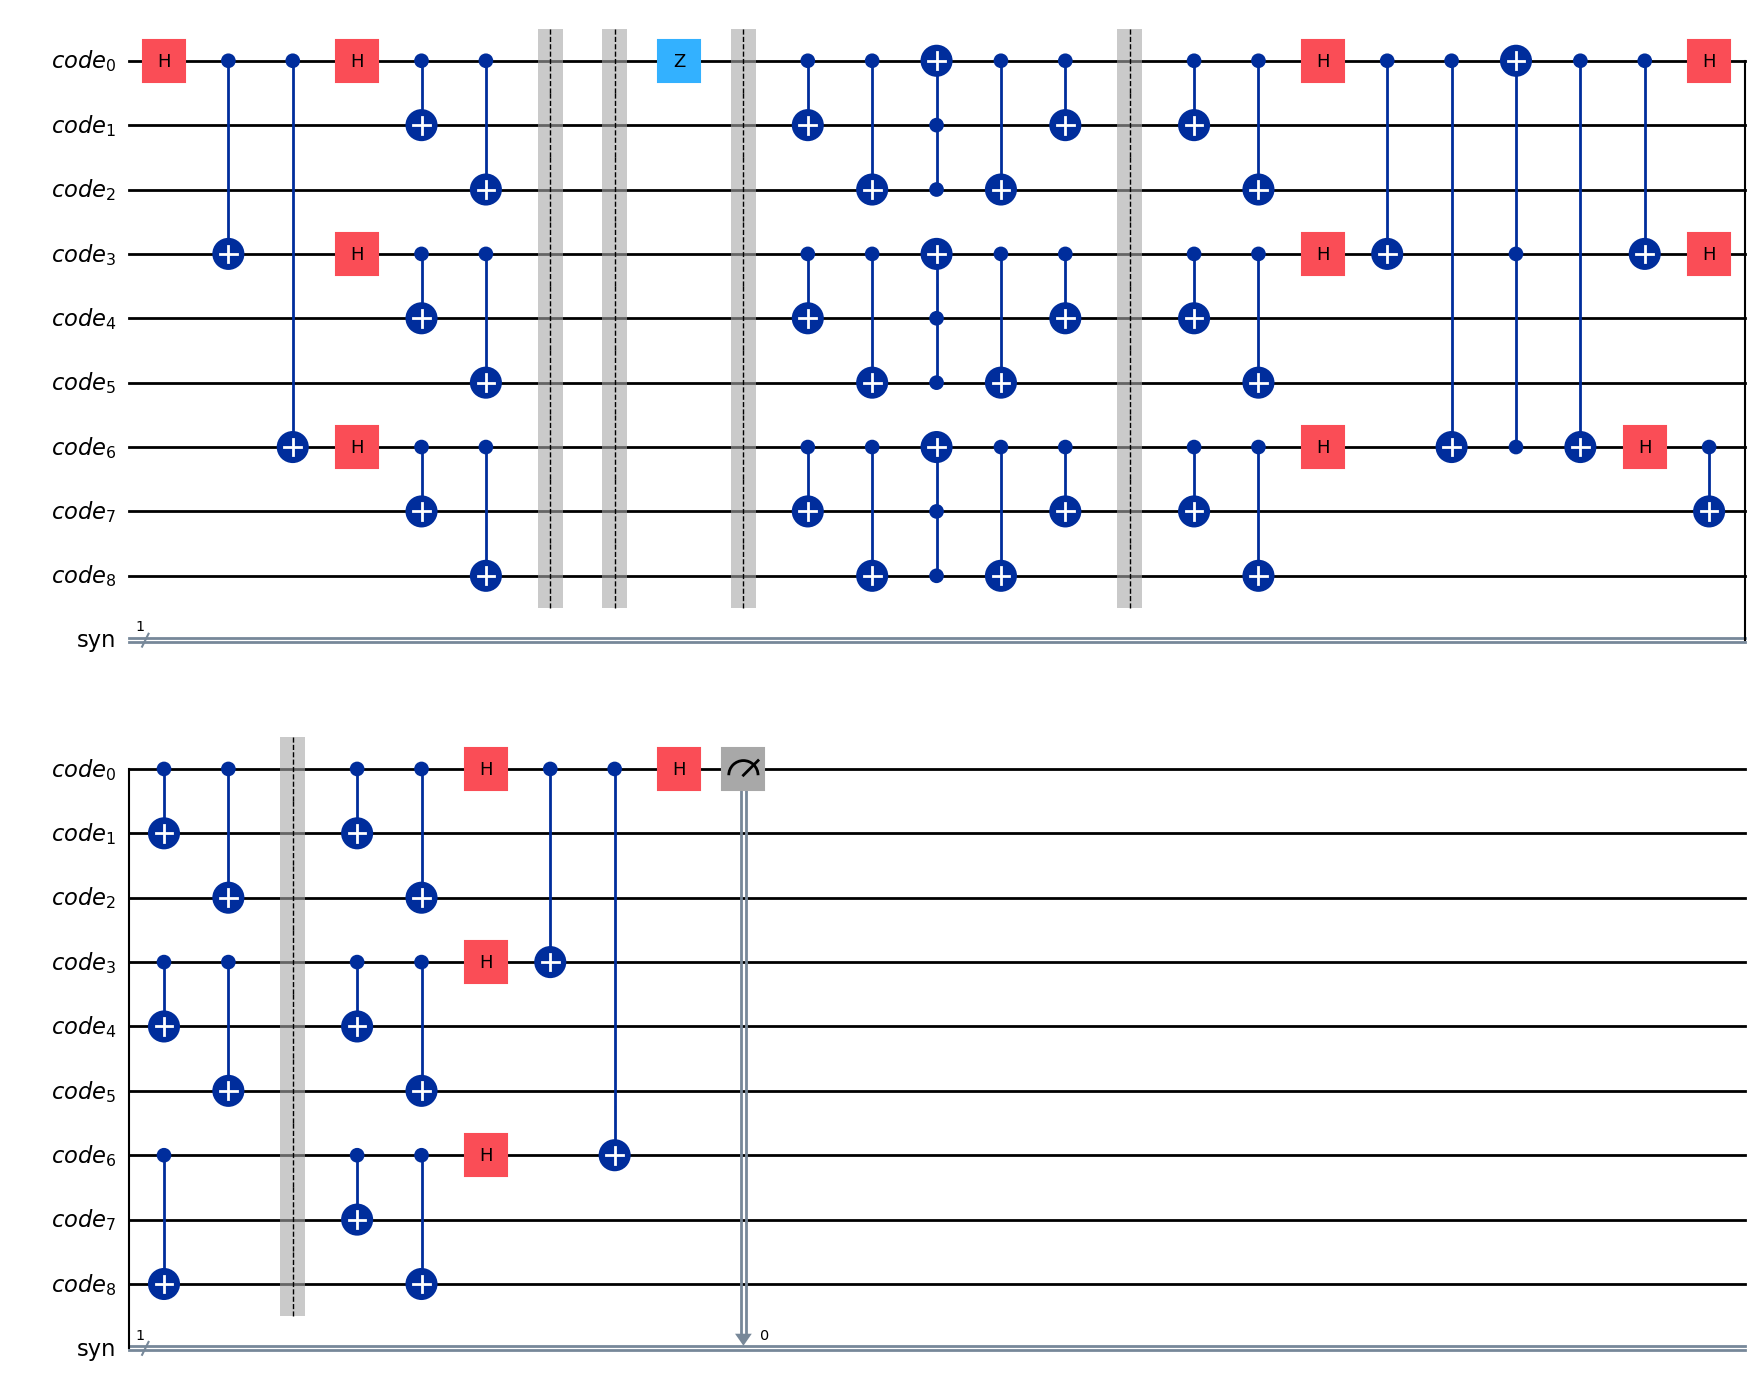

In [ ]:
#error always on same qubit q0

import numpy as np
import random
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

# --- 1. SHOR CODE FUNCTIONS (Same as before) ---

def shor_encode(qc):
    """Encodes 1 qubit into 9 qubits"""
    # Create the Logical structure
    qc.cx(0, 3); qc.cx(0, 6)
    qc.h(0); qc.h(3); qc.h(6)
    qc.cx(0, 1); qc.cx(0, 2)
    qc.cx(3, 4); qc.cx(3, 5)
    qc.cx(6, 7); qc.cx(6, 8)
    qc.barrier()

def shor_correct(qc):
    """Corrects errors on the 9-qubit block"""
    # 1. Bit Flip Correction
    for i in [0, 3, 6]:
        qc.cx(i, i+1); qc.cx(i, i+2)
        qc.ccx(i+1, i+2, i)
        qc.cx(i, i+2); qc.cx(i, i+1)
    qc.barrier()

    # 2. Phase Flip Correction
    qc.cx(0, 1); qc.cx(0, 2); qc.cx(3, 4); qc.cx(3, 5); qc.cx(6, 7); qc.cx(6, 8)
    qc.h(0); qc.h(3); qc.h(6)
    qc.cx(0, 3); qc.cx(0, 6)
    qc.ccx(3, 6, 0) # Correction happens here
    qc.cx(0, 6); qc.cx(0, 3)
    qc.h(0); qc.h(3); qc.h(6)
    qc.cx(0, 1); qc.cx(0, 2); qc.cx(3, 4); qc.cx(3, 5); qc.cx(6, 7); qc.cx(6, 8)
    qc.barrier()

def shor_decode(qc):
    """Decodes 9 qubits back to 1"""
    qc.cx(0, 1); qc.cx(0, 2)
    qc.cx(3, 4); qc.cx(3, 5)
    qc.cx(6, 7); qc.cx(6, 8)
    qc.h(0); qc.h(3); qc.h(6)
    qc.cx(0, 3); qc.cx(0, 6)

# --- 2. ORACLE & NOISE ---

def logical_constant_oracle(qc, probability=0.8):
    """
    Simulates a Constant Oracle (Identity Operation).
    Noise attacks the system during this operation.
    """
    qc.barrier()
    # Noise Injection
    log = "Clean"
    if random.random() < probability:
        error_type = random.choice(['X', 'Z'])
        if error_type == 'X':
            qc.x(0) # Error on Qubit 0
            log = "X Error"
        else:
            qc.z(0) # Error on Qubit 0
            log = "Z Error"
    qc.barrier()
    return log

# --- 3. BATCH SIMULATION ---

simulator = AerSimulator()
circuits = []
noise_logs = []

print("Generating 100 unique Deutsch Algorithm timelines...")

for i in range(100):
    qr = QuantumRegister(9, 'code')
    cr = ClassicalRegister(1, 'syn')
    qc = QuantumCircuit(qr, cr)

    # --- STEP A: INITIALIZATION (Modified) ---
    # Deutsch starts with Superposition (|+>), not |1>
    qc.h(0)

    # --- STEP B: ENCODE ---
    # This turns |+> into Logical |+>
    shor_encode(qc)

    # --- STEP C: ORACLE (With Noise) ---
    log = logical_constant_oracle(qc, probability=0.8)
    noise_logs.append(log)

    # --- STEP D: CORRECT ---
    shor_correct(qc)

    # --- STEP E: DECODE ---
    shor_decode(qc)

    # --- STEP F: INTERFERENCE (New) ---
    # In Deutsch Algo, we must apply H before measuring
    # |+> becomes |0> (Constant)
    # |-> becomes |1> (Balanced/Error)
    qc.h(0)

    # --- STEP G: MEASURE ---
    qc.measure(0, 0)

    circuits.append(qc)

print("Running batch simulation...")
result = simulator.run(circuits, shots=1).result()

# --- 4. ANALYSIS ---

total_counts = {'0': 0, '1': 0}
x_count = 0; z_count = 0

for i in range(100):
    counts = result.get_counts(i)
    if '0' in counts: total_counts['0'] += 1
    if '1' in counts: total_counts['1'] += 1

    if noise_logs[i] == "X Error": x_count += 1
    if noise_logs[i] == "Z Error": z_count += 1

print("\n--- NOISE STATISTICS ---")
print(f"X Errors: {x_count}, Z Errors: {z_count}, Clean: {100 - x_count - z_count}")

print("\n--- FINAL RESULTS ---")
# Ideally, Constant Oracle = 0.
print(f"Result '0' (Constant/Success): {total_counts['0']}")
print(f"Result '1' (Error/Failure):    {total_counts['1']}")

if total_counts['0'] == 100:
    print("\nSUCCESS: The Shor Code preserved the superposition state!")

display(circuits[-1].draw("mpl"))

Generating 100 unique timelines with RANDOM target qubits...
Running batch simulation...

--- NOISE STATISTICS ---
Total X Errors: 40
Total Z Errors: 39
Total Clean:    21

--- SAMPLE OF ERROR LOCATIONS ---
First 5 X-Errors: ['X on Q8', 'X on Q0', 'X on Q8', 'X on Q0', 'X on Q0']
First 5 Z-Errors: ['Z on Q1', 'Z on Q8', 'Z on Q5', 'Z on Q0', 'Z on Q6']

--- FINAL RESULTS ---
Result '0' (Success): 100
Result '1' (Failure): 0

SUCCESS: The Shor Code corrected errors all over the chip!


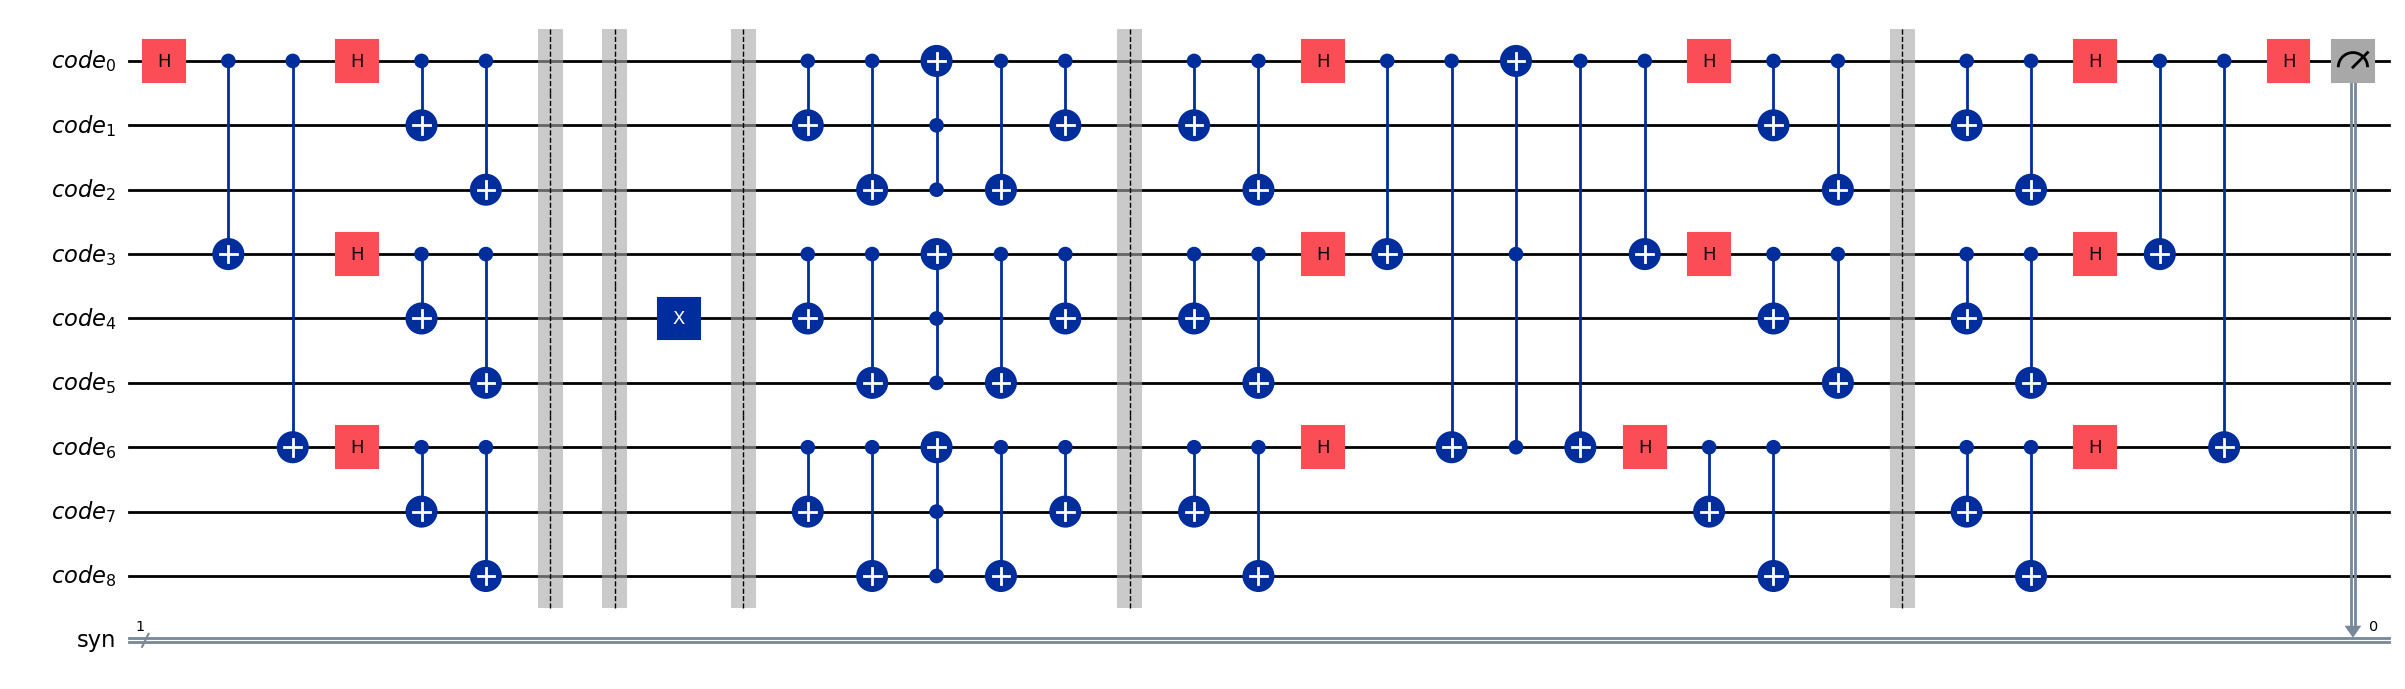

In [ ]:
#error on different qubit's in different circuit

import numpy as np
import random
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

# --- 1. SHOR CODE FUNCTIONS (Same as before) ---
def shor_encode(qc):
    """Encodes 1 qubit into 9 qubits"""
    qc.cx(0, 3); qc.cx(0, 6)
    qc.h(0); qc.h(3); qc.h(6)
    qc.cx(0, 1); qc.cx(0, 2)
    qc.cx(3, 4); qc.cx(3, 5)
    qc.cx(6, 7); qc.cx(6, 8)
    qc.barrier()

def shor_correct(qc):
    """Corrects errors on the 9-qubit block"""
    # 1. Bit Flip Correction
    for i in [0, 3, 6]:
        qc.cx(i, i+1); qc.cx(i, i+2)
        qc.ccx(i+1, i+2, i)
        qc.cx(i, i+2); qc.cx(i, i+1)
    qc.barrier()

    # 2. Phase Flip Correction
    qc.cx(0, 1); qc.cx(0, 2); qc.cx(3, 4); qc.cx(3, 5); qc.cx(6, 7); qc.cx(6, 8)
    qc.h(0); qc.h(3); qc.h(6)
    qc.cx(0, 3); qc.cx(0, 6)
    qc.ccx(3, 6, 0)
    qc.cx(0, 6); qc.cx(0, 3)
    qc.h(0); qc.h(3); qc.h(6)
    qc.cx(0, 1); qc.cx(0, 2); qc.cx(3, 4); qc.cx(3, 5); qc.cx(6, 7); qc.cx(6, 8)
    qc.barrier()

def shor_decode(qc):
    """Decodes 9 qubits back to 1"""
    qc.cx(0, 1); qc.cx(0, 2)
    qc.cx(3, 4); qc.cx(3, 5)
    qc.cx(6, 7); qc.cx(6, 8)
    qc.h(0); qc.h(3); qc.h(6)
    qc.cx(0, 3); qc.cx(0, 6)

# --- 2. ORACLE WITH RANDOM TARGET ---

def logical_constant_oracle(qc, target_qubit, probability=0.8):
    """
    Simulates a Constant Oracle (Identity).
    Noise attacks a SPECIFIC random qubit passed as an argument.
    """
    qc.barrier()
    log = "Clean"

    if random.random() < probability:
        error_type = random.choice(['X', 'Z'])
        if error_type == 'X':
            qc.x(target_qubit) # Uses the random target
            log = f"X on Q{target_qubit}"
        else:
            qc.z(target_qubit) # Uses the random target
            log = f"Z on Q{target_qubit}"

    qc.barrier()
    return log

# --- 3. BATCH SIMULATION ---

simulator = AerSimulator()
circuits = []
noise_logs = []

print("Generating 100 unique timelines with RANDOM target qubits...")

for i in range(100):
    qr = QuantumRegister(9, 'code')
    cr = ClassicalRegister(1, 'syn')
    qc = QuantumCircuit(qr, cr)

    # A. Init |+>
    qc.h(0)

    # B. Encode
    shor_encode(qc)

    # C. ORACLE (With Random Target Selection)
    # Pick a random qubit index from 0 to 8
    random_target = random.randint(0, 8)

    # Pass it to the function
    log = logical_constant_oracle(qc, target_qubit=random_target, probability=0.8)
    noise_logs.append(log)

    # D. Correct
    shor_correct(qc)

    # E. Decode
    shor_decode(qc)

    # F. Interference & Measure
    qc.h(0)
    qc.measure(0, 0)

    circuits.append(qc)

print("Running batch simulation...")
result = simulator.run(circuits, shots=1).result()

# --- 4. ANALYSIS ---

total_counts = {'0': 0, '1': 0}
logs_x = []
logs_z = []

for i in range(100):
    counts = result.get_counts(i)
    if '0' in counts: total_counts['0'] += 1
    if '1' in counts: total_counts['1'] += 1

    # Parse our detailed logs
    if "X" in noise_logs[i]: logs_x.append(noise_logs[i])
    if "Z" in noise_logs[i]: logs_z.append(noise_logs[i])

print("\n--- NOISE STATISTICS ---")
print(f"Total X Errors: {len(logs_x)}")
print(f"Total Z Errors: {len(logs_z)}")
print(f"Total Clean:    {100 - len(logs_x) - len(logs_z)}")

print("\n--- SAMPLE OF ERROR LOCATIONS ---")
print("First 5 X-Errors:", logs_x[:5])
print("First 5 Z-Errors:", logs_z[:5])

print("\n--- FINAL RESULTS ---")
print(f"Result '0' (Success): {total_counts['0']}")
print(f"Result '1' (Failure): {total_counts['1']}")

if total_counts['0'] == 100:
    print("\nSUCCESS: The Shor Code corrected errors all over the chip!")

display(circuits[-1].draw("mpl",fold=-1)) #fold: This parameter controls how many "units" wide the circuit can be before it splits to a new line.-1:
                                          # -1, This specific value is a command to "never fold." It forces the drawer to expand the image width as much as necessary to keep everything on one row.
